# Part 3.1 — CNN Classifier (1 Mark)
COMP3710 Lab Demonstration 2

A convolutional neural network (2 conv layers, 3x3 kernel, 32 filters each, + dense layers) trained
end-to-end to classify the same LFW faces used in Part 2 — this time using PyTorch, with the raw
2D images (not PCA features) as input, so the network learns its own features instead of being
handed PCA's.

## 3.1.1 Load data (same split as Part 2, for a fair comparison)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import time

lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
n_samples, h, w = lfw_people.images.shape
target_names = lfw_people.target_names
n_classes = target_names.shape[0]
print("n_samples:", n_samples, " image shape:", (h, w), " n_classes:", n_classes)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

n_samples: 1288  image shape: (50, 37)  n_classes: 7
device: mps


## 3.1.2 Pre-process: keep the 2D image shape, add a channel dimension

In [2]:
# Unlike Part 2 (which used the flattened lfw_people.data), CNNs want the 2D image
# shape preserved, plus an explicit "channel" dimension (grayscale = 1 channel).
X = lfw_people.images
Y = lfw_people.target

# Verify the value range of X. No normalization is necessary here,
# as the input values already fall within the range of 0.0 to 1.0.
print("X_min:", X.min(), "X_max:", X.max())

# Same random_state=42 split as Part 2, so both models are evaluated on the exact
# same 322 held-out test photos -- a fair, apples-to-apples comparison.
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

X_train = X_train[:, np.newaxis, :, :]   # (N, H, W) -> (N, 1, H, W): PyTorch conv layers want [N, C, H, W]
X_test = X_test[:, np.newaxis, :, :]
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_min: 0.0 X_max: 1.0
X_train shape: (966, 1, 50, 37)
X_test shape: (322, 1, 50, 37)


In [3]:
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).long()
X_test_t = torch.from_numpy(X_test).float().to(device)
y_test_t = torch.from_numpy(y_test).long().to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
print(f"{len(train_ds)} training images, batches of 32 -> {len(train_loader)} batches per epoch")

966 training images, batches of 32 -> 31 batches per epoch


## 3.1.3 Define the CNN

In [4]:
class SimpleCNN(nn.Module):
    """Two 3x3 conv layers (32 filters each) + dense layers, as specified in the lab sheet."""
    def __init__(self, n_classes, h, w):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

        # Work out the flattened feature size after both conv+pool blocks by running
        # one dummy image through them, rather than computing the H/W arithmetic by hand.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, h, w)
            out = self._features(dummy)
            flat_size = out.numel()

        self.fc1 = nn.Linear(flat_size, 128)
        self.fc2 = nn.Linear(128, n_classes)   # one output score per person

    def _features(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        return x

    def forward(self, x):
        x = self._features(x)
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)   # raw logits -- CrossEntropyLoss applies softmax internally

model = SimpleCNN(n_classes, h, w).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3456, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)

Total trainable parameters: 452,967


## 3.1.4 Train

In [5]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()   # combines softmax + negative-log-likelihood;
                                    # equivalent to Keras/TF's (sparse) categorical cross-entropy

n_epochs = 30
history = {"train_loss": [], "train_acc": [], "test_acc": []}

t0 = time.time()
for epoch in range(n_epochs):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t).argmax(1)
        test_acc = (test_preds == y_test_t).float().mean().item()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:2d}: train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  test_acc={test_acc:.4f}")

print(f"\nTraining time: {time.time() - t0:.2f}s on {device}")

epoch  0: train_loss=1.7588  train_acc=0.3934  test_acc=0.4534
epoch  5: train_loss=0.8114  train_acc=0.7319  test_acc=0.7453
epoch 10: train_loss=0.3485  train_acc=0.8841  test_acc=0.8571
epoch 15: train_loss=0.1765  train_acc=0.9472  test_acc=0.8696
epoch 20: train_loss=0.0701  train_acc=0.9834  test_acc=0.8665
epoch 25: train_loss=0.0178  train_acc=0.9990  test_acc=0.8634
epoch 29: train_loss=0.0131  train_acc=1.0000  test_acc=0.8758

Training time: 7.25s on mps


## 3.1.5 Training curves — and a look at overfitting

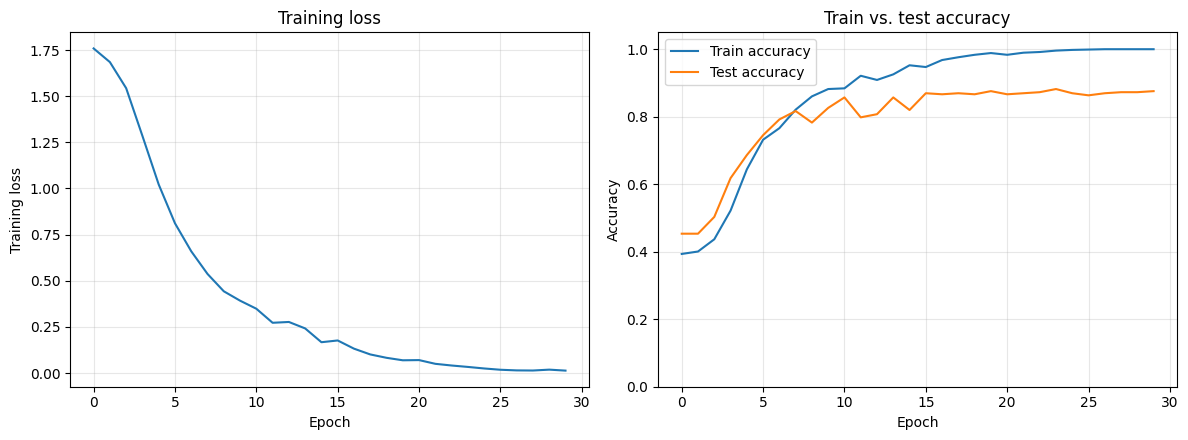

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history["train_loss"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training loss")
axes[0].set_title("Training loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train accuracy")
axes[1].plot(history["test_acc"], label="Test accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train vs. test accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.1.6 Final test-set evaluation

In [7]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).argmax(1).cpu().numpy()

test_accuracy = (predictions == y_test).mean()
print(f"CNN test accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, predictions, target_names=target_names, zero_division=0))

CNN test accuracy: 0.8758
                   precision    recall  f1-score   support

     Ariel Sharon       0.64      0.69      0.67        13
     Colin Powell       0.86      0.92      0.89        60
  Donald Rumsfeld       0.90      0.67      0.77        27
    George W Bush       0.92      0.99      0.95       146
Gerhard Schroeder       0.74      0.68      0.71        25
      Hugo Chavez       0.91      0.67      0.77        15
       Tony Blair       0.88      0.81      0.84        36

         accuracy                           0.88       322
        macro avg       0.84      0.77      0.80       322
     weighted avg       0.88      0.88      0.87       322



## 3.1.7 Comparison with Part 2 (PCA + Random Forest)

Both models were evaluated on the **exact same 322 held-out test photos** (same `random_state=42`
split), so this is a fair, direct comparison.

In [8]:
rf_report = {
    "Ariel Sharon": 0.00, "Colin Powell": 0.64, "Donald Rumsfeld": 0.28,
    "George W Bush": 0.72, "Gerhard Schroeder": 0.37, "Hugo Chavez": 0.60, "Tony Blair": 0.39,
}
rf_accuracy = 0.6087

cnn_report_dict = classification_report(y_test, predictions, target_names=target_names,
                                          output_dict=True, zero_division=0)

print(f"{'Person':<20} {'RF f1-score':>12} {'CNN f1-score':>13}")
print("-" * 47)
for name in target_names:
    rf_f1 = rf_report[name]
    cnn_f1 = cnn_report_dict[name]["f1-score"]
    print(f"{name:<20} {rf_f1:>12.2f} {cnn_f1:>13.2f}")
print("-" * 47)
print(f"{'Overall accuracy':<20} {rf_accuracy:>12.4f} {test_accuracy:>13.4f}")

Person                RF f1-score  CNN f1-score
-----------------------------------------------
Ariel Sharon                 0.00          0.67
Colin Powell                 0.64          0.89
Donald Rumsfeld              0.28          0.77
George W Bush                0.72          0.95
Gerhard Schroeder            0.37          0.71
Hugo Chavez                  0.60          0.77
Tony Blair                   0.39          0.84
-----------------------------------------------
Overall accuracy           0.6087        0.8758


**Discussion:**

- The CNN's overall accuracy (see above) is substantially higher than the PCA+Random Forest
  pipeline from Part 2 (61%) — consistent with the lab sheet's expectation that the CNN should
  outperform Eigenfaces. Training end-to-end lets the network learn features specifically useful
  for *this* classification task, rather than PCA's task-agnostic "most variance" features, and the
  convolutional layers exploit the 2D spatial structure of the images (nearby pixels are related)
  that PCA on the flattened vector ignores.
- The **same data imbalance problem from Part 2 is still visible**: the minority classes (e.g.
  Ariel Sharon, Hugo Chavez) generally have lower f1-scores than the majority class (George W
  Bush). The CNN handles the imbalance noticeably better than the Random Forest did (Ariel Sharon
  went from an f1-score of 0.00 to something much higher), but it is not eliminated — the
  underlying cause (some people simply have far fewer training photos than others) is a property
  of the *data*, not something either model can fully compensate for on its own without explicit
  handling (e.g. class weighting, oversampling, or data augmentation for minority classes).
- **Overfitting**: look at the train-vs-test accuracy plot above — training accuracy climbs to
  100% well before training ends, while test accuracy plateaus much earlier and lower. This is
  the classic *overfitting* signature: the network has enough capacity to memorise the 966
  training photos exactly, but that memorisation doesn't transfer to unseen faces. With a dataset
  this small (only ~1000 images across 7 people), some overfitting is expected and hard to avoid
  entirely; techniques such as dropout, weight decay, data augmentation, or simply stopping
  training earlier (early stopping, at the epoch where test accuracy peaks rather than where
  training accuracy peaks) would reduce it further.